<a href="https://colab.research.google.com/github/nurulaulia21/boothcamp-day--4/blob/main/Nurul_Aulia_Badawi_13020240004.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Load & lihat data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("psychological_regulation_dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (10000, 25)


,Student_ID,Age,Gender,Academic_Year,Department,Sleep_Hours,Screen_Time,Attendance,Assignment_Load,Exam_Pressure,...,Heart_Rate,Stress_Score,Stress_Level,Anxiety_Score,Anxiety_Level,Mood_State,Previous_Intervention,Intervention_Response,Reward_Score,Final_State
0,1,24,Other,1st,CSE,8.0,3.5,90.1,5,7,...,112,4.75,Medium,3.92,Low,Neutral,Stretching Suggestion,0.68,7.50,Relaxed
1,2,19,Male,2nd,ECE,7.6,9.5,55.0,5,1,...,86,2.69,Low,2.20,Low,Calm,No Action,0.38,6.82,Neutral
2,3,20,Other,1st,BBA,5.9,9.9,76.0,5,3,...,73,4.10,Medium,3.73,Low,Neutral,Motivational Message,0.74,7.46,Relaxed
3,4,21,Male,2nd,ARTS,5.2,7.5,82.4,8,3,...,65,5.28,Medium,4.98,Medium,Neutral,Motivational Message,0.56,4.89,Stress
4,5,19,Male,4th,MECH,7.9,9.5,95.3,8,7,...,77,6.21,Medium,4.43,Medium,Neutral,Peer Support,0.66,6.62,Neutral


## Data Understanding

In [2]:
df.info()
print("\nMissing values:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())

print("\nDistribusi target (Stress_Level):")
print(df["Stress_Level"].value_counts())
print(df["Stress_Level"].value_counts(normalize=True).round(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  int64  
 2   Gender                 10000 non-null  object 
 3   Academic_Year          10000 non-null  object 
 4   Department             10000 non-null  object 
 5   Sleep_Hours            10000 non-null  float64
 6   Screen_Time            10000 non-null  float64
 7   Attendance             10000 non-null  float64
 8   Assignment_Load        10000 non-null  int64  
 9   Exam_Pressure          10000 non-null  int64  
 10  Social_Support         10000 non-null  int64  
 11  Physical_Activity      10000 non-null  float64
 12  Caffeine_Intake        10000 non-null  int64  
 13  Study_Hours            10000 non-null  float64
 14  Facial_Emotion         10000 non-null  object 
 15  Hea

## Drop kolom bocor (data leakage) & tentukan target

In [3]:
leak_cols = ["Student_ID", "Stress_Score"]
df_model = df.drop(columns=leak_cols)

target = "Stress_Level"
print("Kolom yang dipakai:", df_model.columns.tolist())

Kolom yang dipakai: ['Age', 'Gender', 'Academic_Year', 'Department', 'Sleep_Hours', 'Screen_Time', 'Attendance', 'Assignment_Load', 'Exam_Pressure', 'Social_Support', 'Physical_Activity', 'Caffeine_Intake', 'Study_Hours', 'Facial_Emotion', 'Heart_Rate', 'Stress_Level', 'Anxiety_Score', 'Anxiety_Level', 'Mood_State', 'Previous_Intervention', 'Intervention_Response', 'Reward_Score', 'Final_State']


## EDA singkat

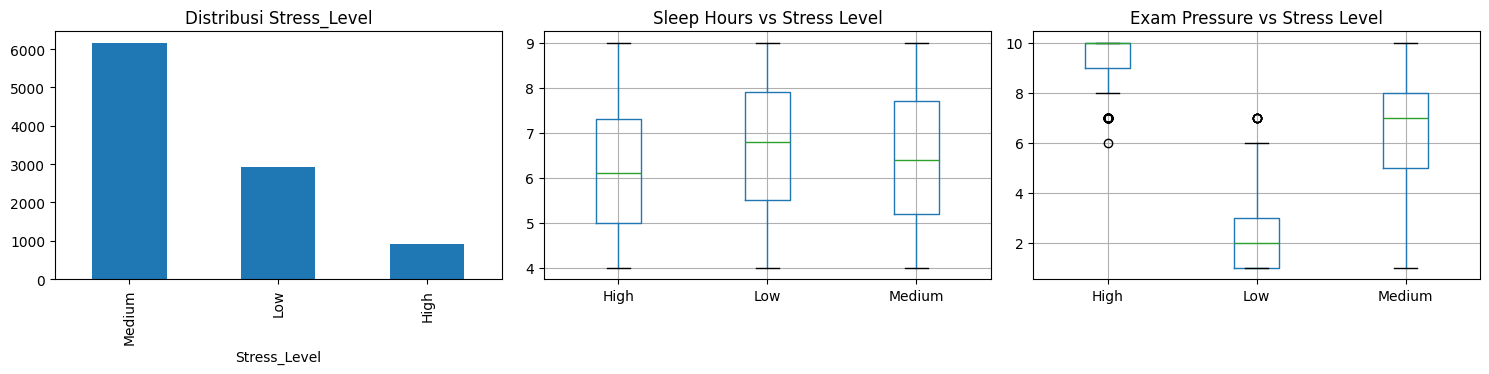

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df[target].value_counts().plot(kind="bar", ax=axes[0], title="Distribusi Stress_Level")

df.boxplot(column="Sleep_Hours", by=target, ax=axes[1])
axes[1].set_title("Sleep Hours vs Stress Level")
axes[1].set_xlabel("")

df.boxplot(column="Exam_Pressure", by=target, ax=axes[2])
axes[2].set_title("Exam Pressure vs Stress Level")
axes[2].set_xlabel("")

plt.suptitle("")
plt.tight_layout()
plt.show()

# Pisahkan fitur numerik & kategorikal

In [5]:
X = df_model.drop(columns=[target])
y = df_model[target]

categorical_cols = X.select_dtypes(include="object").columns.tolist()
numerical_cols = X.select_dtypes(exclude="object").columns.tolist()

print("Kategorikal:", categorical_cols)
print("Numerik:", numerical_cols)

Kategorikal: ['Gender', 'Academic_Year', 'Department', 'Facial_Emotion', 'Anxiety_Level', 'Mood_State', 'Previous_Intervention', 'Final_State']
Numerik: ['Age', 'Sleep_Hours', 'Screen_Time', 'Attendance', 'Assignment_Load', 'Exam_Pressure', 'Social_Support', 'Physical_Activity', 'Caffeine_Intake', 'Study_Hours', 'Heart_Rate', 'Anxiety_Score', 'Intervention_Response', 'Reward_Score']


## Train-test split

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (8000, 22) Test: (2000, 22)


## Preprocessing pipeline

In [7]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
])

## Training & bandingkan 3 model

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42),
    "SVM (RBF)": SVC(class_weight="balanced", random_state=42, probability=True),
}

results = []
fitted_pipelines = {}

for name, clf in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", clf),
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    fitted_pipelines[name] = pipe

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision Macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall Macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1 Macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
    })

results_df = pd.DataFrame(results).sort_values("F1 Macro", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision Macro,Recall Macro,F1 Macro
0,Logistic Regression,0.9995,0.999729,0.998179,0.998951
1,Random Forest,0.9995,0.999729,0.998179,0.998951
2,SVM (RBF),0.9995,0.999729,0.998179,0.998951


## Evaluasi model terbaik

Model terbaik: Logistic Regression
              precision    recall  f1-score   support

        High     1.0000    0.9945    0.9973       183
         Low     1.0000    1.0000    1.0000       586
      Medium     0.9992    1.0000    0.9996      1231

    accuracy                         0.9995      2000
   macro avg     0.9997    0.9982    0.9990      2000
weighted avg     0.9995    0.9995    0.9995      2000



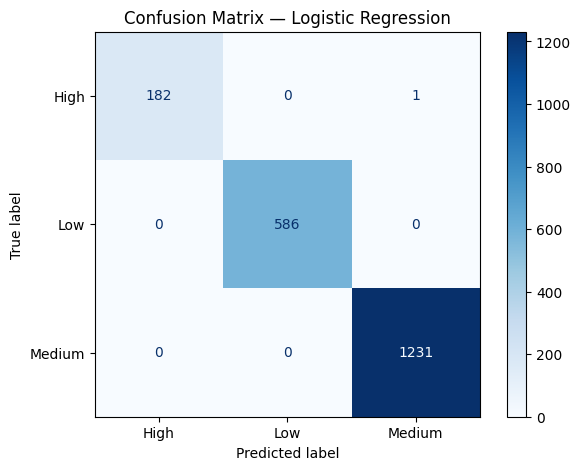

In [9]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

best_name = results_df.loc[0, "Model"]
best_pipe = fitted_pipelines[best_name]
y_pred_best = best_pipe.predict(X_test)

print("Model terbaik:", best_name)
print(classification_report(y_test, y_pred_best, digits=4))

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, ax=ax, cmap="Blues")
plt.title(f"Confusion Matrix — {best_name}")
plt.show()

## Feature importance (kalau Random Forest yang menang)

In [10]:
if best_name == "Random Forest":
    feature_names = (
        numerical_cols +
        list(best_pipe.named_steps["preprocessor"]
             .named_transformers_["cat"]
             .get_feature_names_out(categorical_cols))
    )
    importances = best_pipe.named_steps["classifier"].feature_importances_

    feat_imp = pd.DataFrame({"feature": feature_names, "importance": importances}) \
        .sort_values("importance", ascending=False).head(15)

    plt.figure(figsize=(9, 6))
    plt.barh(feat_imp["feature"], feat_imp["importance"])
    plt.gca().invert_yaxis()
    plt.title("Top 15 Feature Importance")
    plt.tight_layout()
    plt.show()
else:
    print(f"Model terbaik adalah {best_name}, feature importance plot ini khusus untuk Random Forest.")

Model terbaik adalah Logistic Regression, feature importance plot ini khusus untuk Random Forest.


## Prediksi data baru

In [13]:
def predict_stress(new_data: dict):
    df_new = pd.DataFrame([new_data])
    pred = best_pipe.predict(df_new)
    return pred[0]

contoh = {
    "Age": 21, "Gender": "Female", "Academic_Year": "3rd", "Department": "CSE",
    "Sleep_Hours": 4.5, "Screen_Time": 9.0, "Attendance": 60.0,
    "Assignment_Load": 8, "Exam_Pressure": 9, "Social_Support": 2,
    "Physical_Activity": 0.2, "Caffeine_Intake": 4, "Study_Hours": 6.5,
    "Facial_Emotion": "Fear", "Heart_Rate": 105,
    "Anxiety_Score": 6.5, "Anxiety_Level": "High", "Mood_State": "Tense",
    "Previous_Intervention": "No Action", "Intervention_Response": 0.3, "Reward_Score": 3.2,
    "Final_State": "Neutral"
}

pred = predict_stress(contoh)
print("Prediksi Stress Level:", pred)

Prediksi Stress Level: High
